In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import os
# print(os.getcwd())

In [2]:

csv_path = "../data/results/final_merged/haas.csv"
df = pd.read_csv(csv_path) 

df.columns = df.columns.str.strip()

In [3]:
# Ensure correct dtypes
bool_cols = ["judge_answer_correctness_vs_ref", "judge_answer_helpfulness"]
for col in bool_cols:
    if df[col].dtype != bool:
        df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])

numeric_cols = ["meta_total_tokens"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [4]:

# --- Clean up total_elapsed_time column ---
def parse_seconds(x):
    """Convert strings like '12 seconds' or '1.5 s' to float seconds."""
    if pd.isna(x):
        return None
    import re
    match = re.search(r"([\d\.]+)", str(x))
    return float(match.group(1)) if match else None

df["total_elapsed_time_sec"] = df["total_elapsed_time"].apply(parse_seconds)


# --- ESTIMATED price per run ---
def compute_price(row):
    """
    Compute cost (in USD) based on model type and total tokens.
    Prices per 1M tokens:
      gpt-nano: $0.40
      gpt-mini: $2.00
    """
    tokens = row.get("meta_total_tokens", 0)
    model = str(row.get("model", "")).lower()
    
    if "nano" in model:
        price_per_million = 0.40
    elif "mini" in model:
        price_per_million = 2.00
    else:
        # Default if model not recognized
        price_per_million = 1.00  

    return (tokens / 1_000_000) * price_per_million

df["price_usd"] = df.apply(compute_price, axis=1)

# --- Group and Aggregate ---
group_cols = ["approach", "model", "top_k"]

agg_df = (
    df.groupby(group_cols)
      .agg(
          avg_meta_total_tokens=("meta_total_tokens", "mean"),
          avg_price_usd=("price_usd", "mean"),
          avg_latency_sec=("total_elapsed_time_sec", "mean"),
          true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
          total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
          true_helpfulness_count=("judge_answer_helpfulness", "sum"),
          total_helpfulness_count=("judge_answer_helpfulness", "count"),
      )
      .reset_index()
)

In [5]:
# Add percentage columns
agg_df["pct_correctness_true"] = (
    agg_df["true_correctness_count"] / agg_df["total_correctness_count"] * 100
)
agg_df["pct_helpfulness_true"] = (
    agg_df["true_helpfulness_count"] / agg_df["total_helpfulness_count"] * 100
)

In [6]:

# --- Summary ---
print("Summary of metrics by (approach, model, top_k):")
display(agg_df)

Summary of metrics by (approach, model, top_k):


,approach,model,top_k,avg_meta_total_tokens,avg_price_usd,avg_latency_sec,true_correctness_count,total_correctness_count,true_helpfulness_count,total_helpfulness_count,pct_correctness_true,pct_helpfulness_true
0,graph_eager,gpt-5-mini-2025-08-07,3,1848.519608,0.003697,7.029608,43,102,53,102,42.156863,51.960784
1,graph_eager,gpt-5-mini-2025-08-07,7,1847.343137,0.003695,6.966373,42,102,54,102,41.176471,52.941176
2,graph_eager,gpt-5-nano-2025-08-07,3,1889.245098,0.000756,6.789804,33,102,41,102,32.352941,40.196078
3,graph_eager,gpt-5-nano-2025-08-07,7,1884.941176,0.000754,6.325882,34,102,45,102,33.333333,44.117647
4,graph_mmr,gpt-5-mini-2025-08-07,3,3111.931373,0.006224,7.499020,55,102,60,102,53.921569,58.823529
5,graph_mmr,gpt-5-mini-2025-08-07,7,3109.137255,0.006218,9.244412,55,102,62,102,53.921569,60.784314
6,graph_mmr,gpt-5-nano-2025-08-07,3,3135.617647,0.001254,7.206471,44,102,52,102,43.137255,50.980392
7,graph_mmr,gpt-5-nano-2025-08-07,7,3149.892157,0.001260,6.815392,46,102,55,102,45.098039,53.921569
8,lc_bm25,gpt-5-mini-2025-08-07,3,11902.215686,0.023804,6.168431,54,102,63,102,52.941176,61.764706
9,lc_bm25,gpt-5-mini-2025-08-07,7,25798.872549,0.051598,6.483725,68,102,80,102,66.666667,78.431373


In [7]:

# --- Heatmap comparison ---
heatmap_df = (
    agg_df.groupby(["approach", "model"])
    [["pct_correctness_true", "pct_helpfulness_true"]]
    .mean()
    .reset_index()
)

In [8]:
# =======================================
# Section 8: Evaluate Best Combinations
# =======================================

# Sort and display top combinations by correctness
best_correctness = agg_df.sort_values("pct_correctness_true", ascending=False)
best_helpfulness = agg_df.sort_values("pct_helpfulness_true", ascending=False)

print("\nTop combinations by % Correctness TRUE:")
display(best_correctness[[
    "approach", "model", "top_k", 
    "pct_correctness_true",
]])

print("\nTop combinations by % Helpfulness TRUE:")
display(best_helpfulness[[
    "approach", "model", "top_k", 
    "pct_helpfulness_true",
]])


Top combinations by % Correctness TRUE:


,approach,model,top_k,pct_correctness_true
21,vanilla,gpt-5-mini-2025-08-07,7,73.529412
13,openai_keyword,gpt-5-mini-2025-08-07,7,72.549020
12,openai_keyword,gpt-5-mini-2025-08-07,3,68.627451
16,openai_semantic,gpt-5-mini-2025-08-07,3,68.627451
17,openai_semantic,gpt-5-mini-2025-08-07,7,68.627451
9,lc_bm25,gpt-5-mini-2025-08-07,7,66.666667
20,vanilla,gpt-5-mini-2025-08-07,3,61.764706
23,vanilla,gpt-5-nano-2025-08-07,7,58.823529
14,openai_keyword,gpt-5-nano-2025-08-07,3,54.901961
15,openai_keyword,gpt-5-nano-2025-08-07,7,54.901961



Top combinations by % Helpfulness TRUE:


,approach,model,top_k,pct_helpfulness_true
13,openai_keyword,gpt-5-mini-2025-08-07,7,83.333333
21,vanilla,gpt-5-mini-2025-08-07,7,81.372549
9,lc_bm25,gpt-5-mini-2025-08-07,7,78.431373
12,openai_keyword,gpt-5-mini-2025-08-07,3,77.450980
16,openai_semantic,gpt-5-mini-2025-08-07,3,76.470588
17,openai_semantic,gpt-5-mini-2025-08-07,7,75.490196
20,vanilla,gpt-5-mini-2025-08-07,3,68.627451
23,vanilla,gpt-5-nano-2025-08-07,7,65.686275
19,openai_semantic,gpt-5-nano-2025-08-07,7,65.686275
15,openai_keyword,gpt-5-nano-2025-08-07,7,63.725490


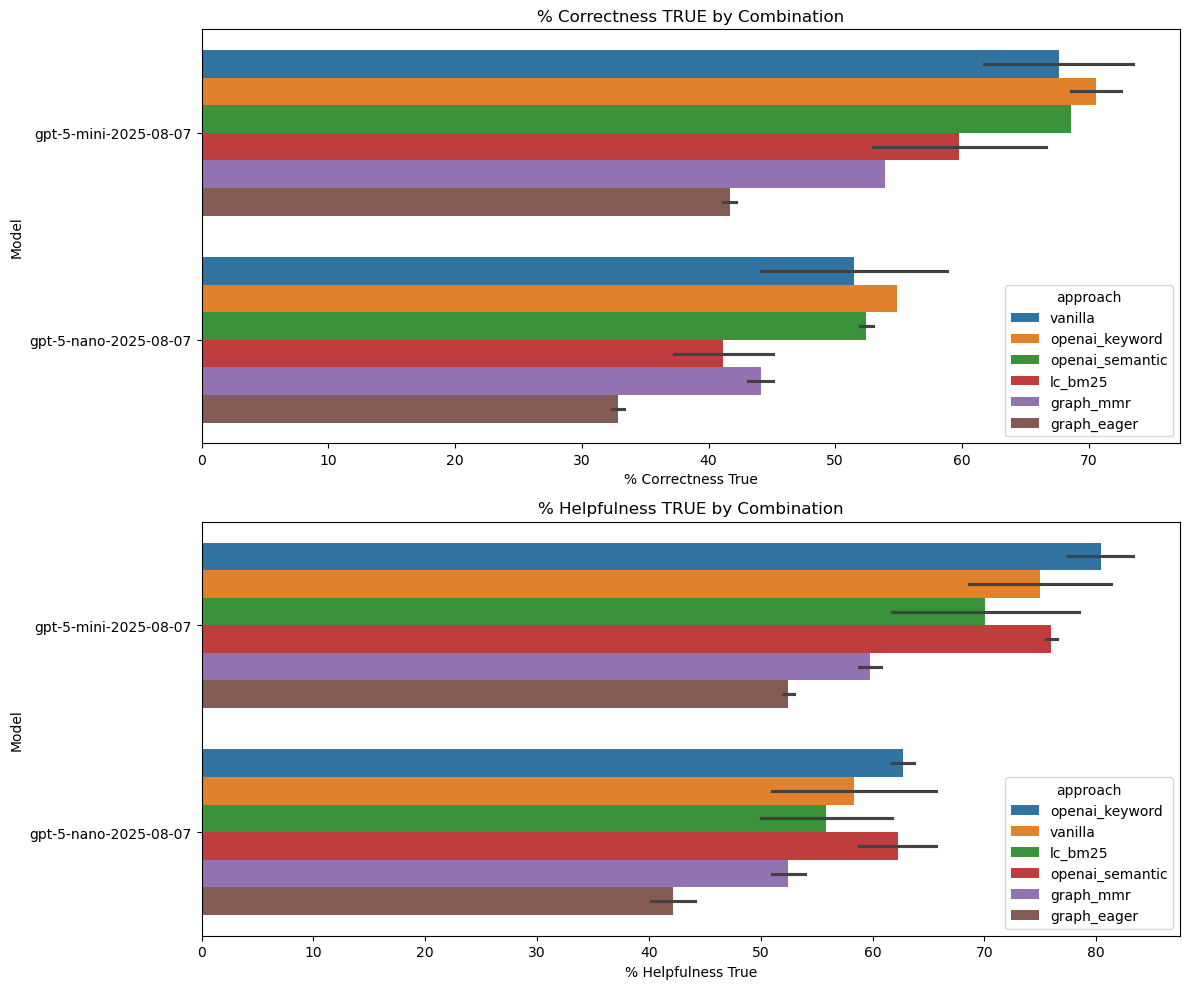

In [9]:
# =======================================
# Visual Comparison Bar Charts
# =======================================

# Combine metrics in one figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.barplot(
    data=agg_df.sort_values("pct_correctness_true", ascending=False),
    x="pct_correctness_true", 
    y="model", 
    hue="approach", 
    ax=axes[0]
)
axes[0].set_title("% Correctness TRUE by Combination")
axes[0].set_xlabel("% Correctness True")
axes[0].set_ylabel("Model")

sns.barplot(
    data=agg_df.sort_values("pct_helpfulness_true", ascending=False),
    x="pct_helpfulness_true", 
    y="model", 
    hue="approach", 
    ax=axes[1]
)
axes[1].set_title("% Helpfulness TRUE by Combination")
axes[1].set_xlabel("% Helpfulness True")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()

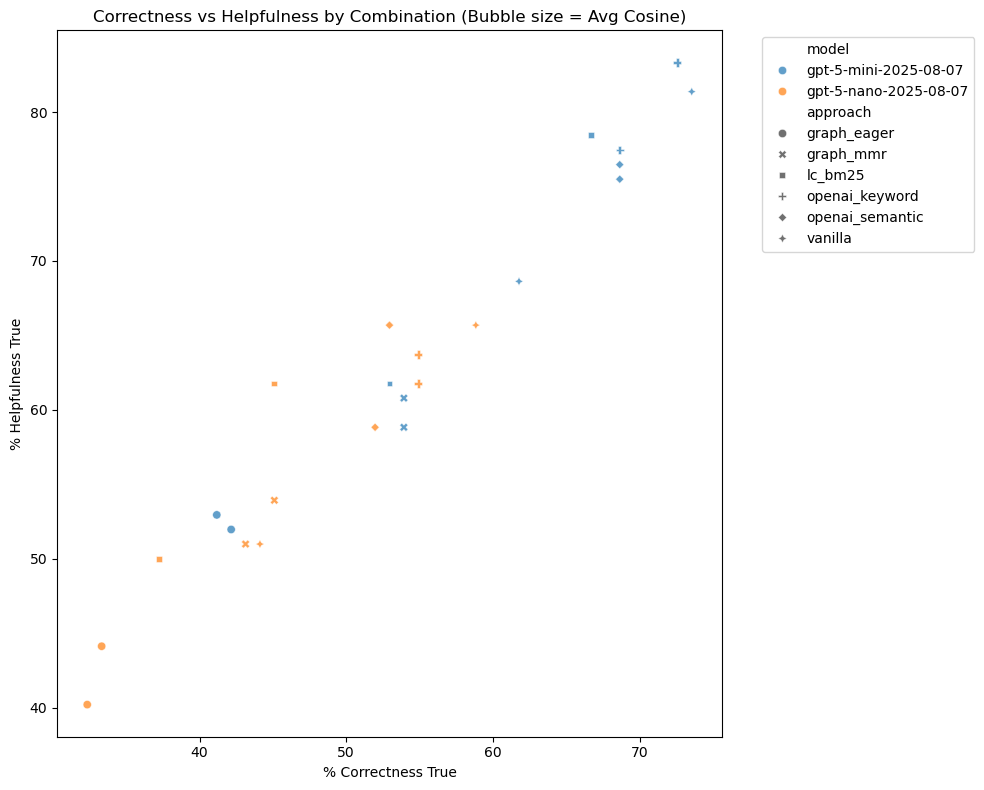

In [10]:
# =======================================
# Annotated Bubble Chart
# =======================================

# Bubble chart: each combination plotted by correctness vs helpfulness
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    data=agg_df,
    x="pct_correctness_true",
    y="pct_helpfulness_true",
    hue="model",
    style="approach",
    sizes=(100, 600),
    alpha=0.7
)
plt.title("Correctness vs Helpfulness by Combination (Bubble size = Avg Cosine)")
plt.xlabel("% Correctness True")
plt.ylabel("% Helpfulness True")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:

# =======================================
# Combined Scoring View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("averaged_score", ascending=False)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Average Correctness and Helpfullness Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Average Correctness and Helpfullness Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
13,0,openai_keyword,gpt-5-mini-2025-08-07,7,7.017255,18297.019608,0.036594,72.549020,83.333333,77.941176
21,1,vanilla,gpt-5-mini-2025-08-07,7,8.256569,8857.127451,0.017714,73.529412,81.372549,77.450980
12,2,openai_keyword,gpt-5-mini-2025-08-07,3,5.734118,8425.813725,0.016852,68.627451,77.450980,73.039216
9,3,lc_bm25,gpt-5-mini-2025-08-07,7,6.483725,25798.872549,0.051598,66.666667,78.431373,72.549020
16,4,openai_semantic,gpt-5-mini-2025-08-07,3,7.292647,8224.176471,0.016448,68.627451,76.470588,72.549020
17,5,openai_semantic,gpt-5-mini-2025-08-07,7,9.159510,17966.313725,0.035933,68.627451,75.490196,72.058824
20,6,vanilla,gpt-5-mini-2025-08-07,3,7.810098,4391.656863,0.008783,61.764706,68.627451,65.196078
23,7,vanilla,gpt-5-nano-2025-08-07,7,7.562745,8929.343137,0.003572,58.823529,65.686275,62.254902
15,8,openai_keyword,gpt-5-nano-2025-08-07,7,5.446176,18324.009804,0.007330,54.901961,63.725490,59.313725
19,9,openai_semantic,gpt-5-nano-2025-08-07,7,7.361569,18018.029412,0.007207,52.941176,65.686275,59.313725


In [12]:
# display(ranked[[
#     "rank", "approach", "model", "top_k", 
#     "pct_correctness_true", "pct_helpfulness_true", "combined_score"
# ]].head(5))

display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]].head(5))

,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
13,0,openai_keyword,gpt-5-mini-2025-08-07,7,7.017255,18297.019608,0.036594,72.549020,83.333333,77.941176
21,1,vanilla,gpt-5-mini-2025-08-07,7,8.256569,8857.127451,0.017714,73.529412,81.372549,77.450980
12,2,openai_keyword,gpt-5-mini-2025-08-07,3,5.734118,8425.813725,0.016852,68.627451,77.450980,73.039216
9,3,lc_bm25,gpt-5-mini-2025-08-07,7,6.483725,25798.872549,0.051598,66.666667,78.431373,72.549020
16,4,openai_semantic,gpt-5-mini-2025-08-07,3,7.292647,8224.176471,0.016448,68.627451,76.470588,72.549020


In [13]:
# =======================================
# Combined Latency View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("avg_latency_sec", ascending=True)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Combined Latency Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Combined Latency Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
10,0,lc_bm25,gpt-5-nano-2025-08-07,3,4.635686,11929.990196,0.004772,37.254902,50.000000,43.627451
14,1,openai_keyword,gpt-5-nano-2025-08-07,3,5.207843,8448.558824,0.003379,54.901961,61.764706,58.333333
15,2,openai_keyword,gpt-5-nano-2025-08-07,7,5.446176,18324.009804,0.007330,54.901961,63.725490,59.313725
12,3,openai_keyword,gpt-5-mini-2025-08-07,3,5.734118,8425.813725,0.016852,68.627451,77.450980,73.039216
11,4,lc_bm25,gpt-5-nano-2025-08-07,7,5.938627,25825.460784,0.010330,45.098039,61.764706,53.431373
8,5,lc_bm25,gpt-5-mini-2025-08-07,3,6.168431,11902.215686,0.023804,52.941176,61.764706,57.352941
3,6,graph_eager,gpt-5-nano-2025-08-07,7,6.325882,1884.941176,0.000754,33.333333,44.117647,38.725490
22,7,vanilla,gpt-5-nano-2025-08-07,3,6.383039,4424.107843,0.001770,44.117647,50.980392,47.549020
9,8,lc_bm25,gpt-5-mini-2025-08-07,7,6.483725,25798.872549,0.051598,66.666667,78.431373,72.549020
2,9,graph_eager,gpt-5-nano-2025-08-07,3,6.789804,1889.245098,0.000756,32.352941,40.196078,36.274510


In [14]:
# =======================================
# Combined Token View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("avg_meta_total_tokens", ascending=True)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Token Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Token Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
1,0,graph_eager,gpt-5-mini-2025-08-07,7,6.966373,1847.343137,0.003695,41.176471,52.941176,47.058824
0,1,graph_eager,gpt-5-mini-2025-08-07,3,7.029608,1848.519608,0.003697,42.156863,51.960784,47.058824
3,2,graph_eager,gpt-5-nano-2025-08-07,7,6.325882,1884.941176,0.000754,33.333333,44.117647,38.725490
2,3,graph_eager,gpt-5-nano-2025-08-07,3,6.789804,1889.245098,0.000756,32.352941,40.196078,36.274510
5,4,graph_mmr,gpt-5-mini-2025-08-07,7,9.244412,3109.137255,0.006218,53.921569,60.784314,57.352941
4,5,graph_mmr,gpt-5-mini-2025-08-07,3,7.499020,3111.931373,0.006224,53.921569,58.823529,56.372549
6,6,graph_mmr,gpt-5-nano-2025-08-07,3,7.206471,3135.617647,0.001254,43.137255,50.980392,47.058824
7,7,graph_mmr,gpt-5-nano-2025-08-07,7,6.815392,3149.892157,0.001260,45.098039,53.921569,49.509804
20,8,vanilla,gpt-5-mini-2025-08-07,3,7.810098,4391.656863,0.008783,61.764706,68.627451,65.196078
22,9,vanilla,gpt-5-nano-2025-08-07,3,6.383039,4424.107843,0.001770,44.117647,50.980392,47.549020


In [15]:
# =======================================
# Combined Price View
# =======================================

# Create a composite ranking score (normalized 0–1)
from sklearn.preprocessing import MinMaxScaler # type: ignore

scaler = MinMaxScaler()
# agg_df[["score_correctness", "score_helpfulness"]] = scaler.fit_transform(
#     agg_df[["pct_correctness_true", "pct_helpfulness_true"]]
# )
agg_df["averaged_score"] = (agg_df["pct_correctness_true"] + agg_df["pct_helpfulness_true"]) / 2

ranked = agg_df.sort_values("avg_price_usd", ascending=True)
ranked["rank"] = 0
print(agg_df.columns)

for idx, (i,row) in enumerate(ranked.iterrows()):
    ranked.loc[i, "rank"] = idx
print("\nRanked by Price Score:")
display(ranked[[
    "rank", "approach", "model", "top_k", "avg_latency_sec", "avg_meta_total_tokens", "avg_price_usd",
    "pct_correctness_true", "pct_helpfulness_true", "averaged_score"
]])

Index(['approach', 'model', 'top_k', 'avg_meta_total_tokens', 'avg_price_usd',
       'avg_latency_sec', 'true_correctness_count', 'total_correctness_count',
       'true_helpfulness_count', 'total_helpfulness_count',
       'pct_correctness_true', 'pct_helpfulness_true', 'averaged_score'],
      dtype='object')

Ranked by Price Score:


,rank,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true,averaged_score
3,0,graph_eager,gpt-5-nano-2025-08-07,7,6.325882,1884.941176,0.000754,33.333333,44.117647,38.725490
2,1,graph_eager,gpt-5-nano-2025-08-07,3,6.789804,1889.245098,0.000756,32.352941,40.196078,36.274510
6,2,graph_mmr,gpt-5-nano-2025-08-07,3,7.206471,3135.617647,0.001254,43.137255,50.980392,47.058824
7,3,graph_mmr,gpt-5-nano-2025-08-07,7,6.815392,3149.892157,0.001260,45.098039,53.921569,49.509804
22,4,vanilla,gpt-5-nano-2025-08-07,3,6.383039,4424.107843,0.001770,44.117647,50.980392,47.549020
18,5,openai_semantic,gpt-5-nano-2025-08-07,3,7.017451,8313.235294,0.003325,51.960784,58.823529,55.392157
14,6,openai_keyword,gpt-5-nano-2025-08-07,3,5.207843,8448.558824,0.003379,54.901961,61.764706,58.333333
23,7,vanilla,gpt-5-nano-2025-08-07,7,7.562745,8929.343137,0.003572,58.823529,65.686275,62.254902
1,8,graph_eager,gpt-5-mini-2025-08-07,7,6.966373,1847.343137,0.003695,41.176471,52.941176,47.058824
0,9,graph_eager,gpt-5-mini-2025-08-07,3,7.029608,1848.519608,0.003697,42.156863,51.960784,47.058824


In [16]:

combo_1 = {
    "approach": "openai_keyword",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 7,
}
combo_2 = {
    "approach": "openai_semantic",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 3,
}

compare_df = df[
    ((df["approach"] == combo_1["approach"]) & 
     (df["model"] == combo_1["model"]) & 
     (df["top_k"] == combo_1["top_k"])) |
    ((df["approach"] == combo_2["approach"]) & 
     (df["model"] == combo_2["model"]) & 
     (df["top_k"] == combo_2["top_k"]))
]

print(f"Subset shape: {compare_df.shape}")
print(compare_df[["approach", "model", "top_k"]].drop_duplicates())

question_compare_df = (
    compare_df.groupby(["question", "approach", "model", "top_k"])
    .agg(
        avg_price_usd=("price_usd", "mean"),
        avg_latency_sec=("total_elapsed_time_sec", "mean"),
        avg_meta_total_tokens=("meta_total_tokens", "mean"),
        true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
        total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
        true_helpfulness_count=("judge_answer_helpfulness", "sum"),
        total_helpfulness_count=("judge_answer_helpfulness", "count"),
    )
    .reset_index()
)

# Derived percentages
question_compare_df["pct_correctness_true"] = (
    question_compare_df["true_correctness_count"]
    / question_compare_df["total_correctness_count"] * 100
)
question_compare_df["pct_helpfulness_true"] = (
    question_compare_df["true_helpfulness_count"]
    / question_compare_df["total_helpfulness_count"] * 100
)

print("\nQuestion-level results for selected configurations:")
display(
    question_compare_df[[
        "question",
        "approach",
        "model",
        "top_k",
        "avg_latency_sec",
        "avg_meta_total_tokens",
        "avg_price_usd",
        "pct_correctness_true",
        "pct_helpfulness_true",
    ]]
    .sort_values(["question", "approach"])
)


Subset shape: (204, 33)
            approach                  model  top_k
51    openai_keyword  gpt-5-mini-2025-08-07      7
408  openai_semantic  gpt-5-mini-2025-08-07      3

Question-level results for selected configurations:


,question,approach,model,top_k,avg_latency_sec,avg_meta_total_tokens,avg_price_usd,pct_correctness_true,pct_helpfulness_true
0,A client wants us to measure all out movements...,openai_keyword,gpt-5-mini-2025-08-07,7,5.870,24381.0,0.048762,100.0,100.0
1,A client wants us to measure all out movements...,openai_semantic,gpt-5-mini-2025-08-07,3,6.865,10786.5,0.021573,100.0,100.0
2,Are there any safety instructions preventing m...,openai_keyword,gpt-5-mini-2025-08-07,7,5.575,16799.0,0.033598,100.0,100.0
3,Are there any safety instructions preventing m...,openai_semantic,gpt-5-mini-2025-08-07,3,4.680,8103.5,0.016207,100.0,100.0
4,Are there any safety warnings associated with ...,openai_keyword,gpt-5-mini-2025-08-07,7,12.255,19706.0,0.039412,0.0,100.0
...,...,...,...,...,...,...,...,...,...
97,What is the Run-Stop-Jog-Continue motion on th...,openai_semantic,gpt-5-mini-2025-08-07,3,7.435,7454.5,0.014909,50.0,50.0
98,What is the turnable handle jog control used f...,openai_keyword,gpt-5-mini-2025-08-07,7,9.750,15540.5,0.031081,100.0,100.0
99,What is the turnable handle jog control used f...,openai_semantic,gpt-5-mini-2025-08-07,3,4.905,8884.0,0.017768,100.0,100.0
100,What setting number prevents the operator from...,openai_keyword,gpt-5-mini-2025-08-07,7,4.090,21800.0,0.043600,100.0,100.0


In [17]:
combo_1 = {
    "approach": "openai_keyword",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 7,
}
combo_2 = {
    "approach": "openai_semantic",
    "model": "gpt-5-mini-2025-08-07",
    "top_k": 3,
}

# --- Filter the main dataframe for just these groups ---
compare_df = df[
    ((df["approach"] == combo_1["approach"]) & 
     (df["model"] == combo_1["model"]) & 
     (df["top_k"] == combo_1["top_k"])) |
    ((df["approach"] == combo_2["approach"]) & 
     (df["model"] == combo_2["model"]) & 
     (df["top_k"] == combo_2["top_k"]))
].copy()

print(f"Subset shape: {compare_df.shape}")
print(compare_df[["approach", "model", "top_k"]].drop_duplicates())

# --- Compute per-question correctness ---
question_compare_df = (
    compare_df.groupby(["question", "approach"])
    .agg(
        true_correctness_count=("judge_answer_correctness_vs_ref", "sum"),
        total_correctness_count=("judge_answer_correctness_vs_ref", "count"),
    )
    .reset_index()
)

# Binary 1/0 correctness per question (100% = True)
question_compare_df["is_correct"] = (
    question_compare_df["true_correctness_count"]
    / question_compare_df["total_correctness_count"]
) == 1.0

# --- Pivot into side-by-side comparison ---
pivot_correct = question_compare_df.pivot_table(
    index="question", columns="approach", values="is_correct"
).reset_index()

# Drop questions not answered by both
pivot_correct = pivot_correct.dropna(subset=[combo_1["approach"], combo_2["approach"]])

# --- Determine which approach "won" each question ---
pivot_correct["winner"] = pivot_correct.apply(
    lambda x: (
        combo_1["approach"]
        if (x[combo_1["approach"]] and not x[combo_2["approach"]])
        else (combo_2["approach"]
              if (x[combo_2["approach"]] and not x[combo_1["approach"]])
              else "tie")
    ),
    axis=1,
)

# --- Split into categories ---
questions_keyword_won = pivot_correct[pivot_correct["winner"] == combo_1["approach"]]
questions_semantic_won = pivot_correct[pivot_correct["winner"] == combo_2["approach"]]
questions_tied = pivot_correct[pivot_correct["winner"] == "tie"]

# --- Display tables ---
print(f"\n{combo_1['approach']} got right where {combo_2['approach']} missed:")
display(questions_keyword_won[["question", combo_1["approach"], combo_2["approach"]]])

print(f"\n{combo_2['approach']} got right where {combo_1['approach']} missed:")
display(questions_semantic_won[["question", combo_1["approach"], combo_2["approach"]]])

print(f"\nQuestions both got right or both missed:")
display(questions_tied[["question", combo_1["approach"], combo_2["approach"]]])

# --- Summary counts ---
summary_counts = pivot_correct["winner"].value_counts().reset_index()
summary_counts.columns = ["winner", "num_questions"]
print("\nSummary of question-level outcomes:")
display(summary_counts)



Subset shape: (204, 33)
            approach                  model  top_k
51    openai_keyword  gpt-5-mini-2025-08-07      7
408  openai_semantic  gpt-5-mini-2025-08-07      3

openai_keyword got right where openai_semantic missed:


approach,question,openai_keyword,openai_semantic
23,If I am unsure about how a program will run on...,1.0,0.0
24,If I want machine-specific information about m...,1.0,0.0
27,If I want to signify to people that may come a...,1.0,0.0
28,"If after I powered on the HAAS Lathe, I want t...",1.0,0.0
30,"In the Net Share for my HAAS Lathe, our folder...",1.0,0.0
48,What is the Run-Stop-Jog-Continue motion on th...,1.0,0.0



openai_semantic got right where openai_keyword missed:


approach,question,openai_keyword,openai_semantic
15,I want to make a change to a program on the HA...,0.0,1.0
35,My display on my HAAS Lathe is showing a yello...,0.0,1.0
36,My display on my HAAS Lathe is showing a yello...,0.0,1.0
41,What are the basic safety equipment a person s...,0.0,1.0



Questions both got right or both missed:


approach,question,openai_keyword,openai_semantic
0,A client wants us to measure all out movements...,1.0,1.0
1,Are there any safety instructions preventing m...,1.0,1.0
2,Are there any safety warnings associated with ...,0.0,0.0
3,"Give me the setting number for ""Max User Trave...",1.0,1.0
4,How do I install a collet on the HAAS Lathe?,0.0,0.0
5,How do I perform a tool load/change on a HAAS ...,0.0,0.0
6,How do I power up the HAAS lathe?,1.0,1.0
7,How do I start the active program after the HA...,1.0,1.0
8,How long can the HAAS machine be idle before i...,1.0,1.0
9,I am encountering an issue/error with the UI o...,1.0,1.0



Summary of question-level outcomes:


,winner,num_questions
0,tie,41
1,openai_keyword,6
2,openai_semantic,4
